# Data preprocess and Anonimization


## Imports

In [11]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Rename the clinics

In [12]:
# Load the CSV and trim whitespace from column names
df = pd.read_csv('MASTER_DATA_FINAL.csv') 
df.columns = df.columns.str.strip()

print("Detected columns:", df.columns.tolist())
print("Target Column (Index 7):", df.columns[7])

# Apply the replacements to index 7
df.iloc[:, 7] = df.iloc[:, 7].astype(str).replace({
    'ΑΙΜΟΛΗΨΙΕ Σ ΕΙ': 'Aimolipsies',
    'ΑΙΜΑΤ. ΑΝΟΣΟΚΑΤΕ ΣΤΑΛΜΕΝΩΝ': 'Aimat. Anosokatestalmena',
    'ΑΝΟΣΟΚΑΤΕΣΤΑΛΜΕΝΩΝ': 'Aimat. Anosokatestalmena',
    'ΚΑΡΔΙΟΛΟΓΙ ΚΗ ΚΛΙΝΙΚΗ': 'Kardiologiki',
    'ΚΑΡΔΙΟΛΟΓΙ ΚΟ': 'Kardiologiki',
    'ΝΕΦΡΟΛΟΓΙ ΚΗ ΚΛΙΝΙΚΗ': 'Nefrologiki',
    'ΝΕΦΡΟΛΟΓΙ ΚΟ ΕΙ': 'Nefrologiki',
    'ΝΕΦΡΟΛΟΓΙ ΚΟ ΕΡΓΑΣΤΗΡΙΟ': 'Nefrologiki',
    'ΝΕΦΡΟΛΟΓΙΚΟ': 'Nefrologiki'
})

# Print unique values of the correct column (Index 7) to verify it worked
print("\nUnique values after rename:")
print(df.iloc[:, 7].unique())

# Save updated CSV
df.to_csv('Preprocessed_DATA.csv', index=False)
print("\nFile saved.")

Detected columns: ['ID', 'First Name', 'Last Name', 'Father Name', 'AM', 'Date', 'Date of Birth', 'Clinic Name', 'Exam ID', 'TSH', 'FT4', 'T3', 'Anti-TPO', 'Anti-TG', 'Gender']
Target Column (Index 7): Clinic Name

Unique values after rename:
['Aimolipsies' 'Aimat. Anosokatestalmena' 'Kardiologiki' 'Nefrologiki']

File saved.


### Plot and Remove patients with complete missing exams 

/tmp/ipykernel_158083/324706582.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=empty_counts, x=clinic_col_name, y='Missing_Tests_Count', palette='viridis')


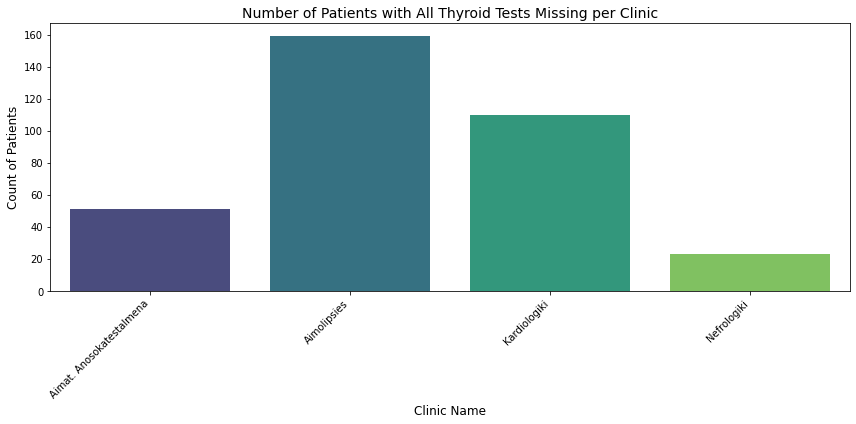

Removed 343 patients with completely missing thyroid panels.

File saved.


In [13]:


# 1. Define the columns to check
thyroid_cols = ["TSH", "FT4", "T3", "Anti-TPO", "Anti-TG"]

# 2. Ensure columns exist and handle empty strings as NaN
# This makes sure that if a cell is just whitespace, it's treated as "empty"
for col in thyroid_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Create a mask where ALL specified columns are null
# df[thyroid_cols].isnull().all(axis=1) returns True only if every col is NaN
empty_thyroid_mask = df[thyroid_cols].isnull().all(axis=1)

# 4. Filter the dataframe and group by the Clinic column (Index 7)
clinic_col_name = df.columns[7]
empty_counts = df[empty_thyroid_mask].groupby(clinic_col_name).size().reset_index(name='Missing_Tests_Count')

# 5. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=empty_counts, x=clinic_col_name, y='Missing_Tests_Count', palette='viridis')

plt.title('Number of Patients with All Thyroid Tests Missing per Clinic', fontsize=14)
plt.xlabel('Clinic Name', fontsize=12)
plt.ylabel('Count of Patients', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


# # ... (Your steps 1 through 3) ...

# 3. Create the mask
empty_thyroid_mask = df[thyroid_cols].isnull().all(axis=1)

# 4. Delete the rows where the mask is True
# We use ~ to keep rows that are NOT all null
df_cleaned = df[~empty_thyroid_mask].copy()

# Optional: Print how many rows were removed
removed_count = empty_thyroid_mask.sum()
print(f"Removed {removed_count} patients with completely missing thyroid panels.")

# Save updated CSV
df_cleaned.to_csv('Preprocessed_DATA.csv', index=False)
print("\nFile saved.")

### Calculate Age

In [14]:
# 1. Convert both columns to proper datetime objects
# dayfirst=True ensures 10/9/1996 is read as Sept 10th, not Oct 9th
df_cleaned = df # Use the cleaned dataframe from the previous step
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Date of Birth'] = pd.to_datetime(df['Date of Birth'], dayfirst=True, errors='coerce')

# 2. Calculate the Age
# This subtracts the years, and then subtracts 1 extra year if the exam 'Date' 
# happened BEFORE the person's birthday in that specific year.
df['Age'] = df['Date'].dt.year - df['Date of Birth'].dt.year - \
            ((df['Date'].dt.month < df['Date of Birth'].dt.month) | 
             ((df['Date'].dt.month == df['Date of Birth'].dt.month) & 
              (df['Date'].dt.day < df['Date of Birth'].dt.day)))
df['Age'] = df['Age'].astype('Int64')

# 3. Print the results to verify


# Save updated CSV
df.to_csv('Preprocessed_DATA.csv', index=False)
print("\nFile saved.")


File saved.


## Create a new key for each patient, so we can later delete AM and make it anonymous

In [15]:
# Create the 'Patient ID' column using factorize
# df['AM'] is the column we are looking at. 
# [0] grabs the actual array of new IDs from the factorize tool.
df['Patient ID'] = pd.factorize(df['AM'])[0] + 1

# Grab a list of all current columns
cols = df.columns.tolist()

# Remove 'Patient ID' from the end and put it at the very beginning
cols.insert(0, cols.pop(cols.index('Patient ID')))

# Reapply the new column order to the dataframe
df = df[cols]


# Save updated CSV
df.to_csv('Preprocessed_DATA.csv', index=False)
print("\nFile saved.")


File saved.


### Anonymize, columns to delete: ID,First Name,Last Name,Father Name,AM,Date,Date of Birth

In [16]:
# Create a list of the exact column names you want to remove
columns_to_delete = ['ID', 'First Name', 'Last Name', 'Father Name', 'AM', 'Date', 'Date of Birth']

# Drop the columns from the dataframe
df = df.drop(columns=columns_to_delete, errors='ignore')

# Print the remaining columns to verify they are gone
print("\nRemaining columns:")
print(df.columns.tolist())

# Save the finalized, clean dataset
df.to_csv('Final_Cleaned_DATA.csv', index=False)
print("\nCleaned file saved successfully.")



Remaining columns:
['Patient ID', 'Clinic Name', 'Exam ID', 'TSH', 'FT4', 'T3', 'Anti-TPO', 'Anti-TG', 'Gender', 'Age']

Cleaned file saved successfully.


### Reorder the CSV

In [17]:
# Define the exact order you want your columns to be in
new_order = [
    'Patient ID', 
    'Clinic Name', 
    'Gender', 
    'Age', 
    'Exam ID', 
    'TSH', 
    'FT4', 
    'T3', 
    'Anti-TPO', 
    'Anti-TG'
]

# Apply the new order to the dataframe
df = df[new_order]

# Print the results to verify it worked perfectly
print("\nNew Column Order:")
print(df.columns.tolist())

# Save the perfectly ordered, final dataset
df.to_csv('Final_Cleaned_DATA.csv', index=False)


New Column Order:
['Patient ID', 'Clinic Name', 'Gender', 'Age', 'Exam ID', 'TSH', 'FT4', 'T3', 'Anti-TPO', 'Anti-TG']
